# Exploratory Data Analysis (EDA) – Fourth  Quarter Sales Dataset

## Project Overview

This notebook presents an exploratory data analysis (EDA) of the cleaned fourth-quarter sales dataset. The analysis aims to explore sales performance, product trends, temporal patterns, and delivery platform performance by applying descriptive statistics and visualizations. The findings provide valuable insights into business performance and establish a foundation for dashboard development and quarterly comparisons.

## Objectives

The main objectives of this analysis are:

- Evaluate the overall sales performance during the fourth quarter.
- Analyze product performance based on revenue, sales quantity, and product returns.
- Identify sales trends across months, weekdays, and hours.
- Evaluate the performance of the major delivery platforms.
- Discover patterns and business insights through descriptive analysis and visualizations.
- Summarize the key findings to support business decision-making and prepare for quarterly and yearly comparisons.

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the Clean Dataset

Load the cleaned fourth-quarter sales dataset and verify its structure before starting the exploratory data analysis.

In [2]:
df = pd.read_excel("../../../Data/Cleaned/clean_q4_data.xlsx", parse_dates=["Date"])

## 3. Dataset Overview

This section provides a general overview of the cleaned dataset, including its dimensions, data types, descriptive statistics, and basic business metrics.

### 3.1 Dataset Shape

In [3]:
df.shape

(53897, 8)

### 3.2 Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53897 entries, 0 to 53896
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            53897 non-null  datetime64[ns]
 1   Receipt Number  53897 non-null  object        
 2   Customer        20828 non-null  object        
 3   Product         53897 non-null  object        
 4   Quantity        53897 non-null  float64       
 5   Unit_Price      53897 non-null  float64       
 6   Subtotal        53897 non-null  float64       
 7   Total           20828 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(3)
memory usage: 3.3+ MB


### 3.3 Descriptive Statistics

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,53897,2025-11-15 19:55:42.260422912,2025-10-01 01:20:27,2025-10-23 16:32:13,2025-11-15 07:38:14,2025-12-09 13:31:36,2025-12-31 23:45:59,NaN
Quantity,53897.0,1.487847,-113.0,1.0,1.0,2.0,115.0,1.719936
Unit_Price,53897.0,11.968393,0.5,4.0,7.0,18.0,220.0,13.466902
Subtotal,53897.0,15.226335,-1582.0,4.0,10.0,20.0,1582.0,20.301875
Total,20828.0,39.419359,-1582.0,12.0,26.4,52.0,1582.0,45.730158


### 3.4 Missing Values Check

In [6]:
df.isna().sum()

Date                  0
Receipt Number        0
Customer          33069
Product               0
Quantity              0
Unit_Price            0
Subtotal              0
Total             33069
dtype: int64

> **Note:** The missing values in the **Customer** and **Total** columns are expected and do not indicate data quality issues. Customer information is only recorded for transactions associated with registered customers or delivery applications, while many in-store transactions do not contain customer names. Similarly, the **Total** value represents the overall amount of an entire receipt and is intentionally stored only once for each transaction rather than being repeated for every product line. Therefore, these missing values were retained as they accurately reflect the original transaction structure.

### 3.5 Duplicate Records Check

In [7]:
df.duplicated().sum()

np.int64(0)

### 3.6 Date Range

In [8]:
print(df["Date"].min())
print(df["Date"].max())

2025-10-01 01:20:27
2025-12-31 23:45:59


### 3.7 Business Summary

In [9]:
print(f"Total Records : {len(df):,}")
print(f"Unique Orders : {df['Receipt Number'].nunique():,}")
print(f"Unique Products : {df['Product'].nunique():,}")
print(f"Unique Customers : {df['Customer'].nunique():,}")

Total Records : 53,897
Unique Orders : 20,819
Unique Products : 169
Unique Customers : 792


## 4. Sales Performance Analysis

This section evaluates the overall sales performance during the fourth quarter by calculating key business metrics. These key performance indicators (KPIs) provide an overview of the sales volume, revenue, and transaction characteristics, serving as a foundation for the subsequent analyses.

### 4.1 Total Revenue

In [10]:
total_revenue = df["Subtotal"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 820,653.80


### 4.2 Total Quantity Sold

In [11]:
total_quantity = df["Quantity"].sum()

print(f"Total Quantity Sold: {total_quantity:,.0f}")

Total Quantity Sold: 80,190


### 4.3 Total Orders

In [12]:
total_orders = df["Receipt Number"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 20,819


### 4.4 Average Order Value (AOV)

In [13]:
average_order_value = (
    df.groupby("Receipt Number")["Subtotal"]
      .sum()
      .mean()
)

print(f"Average Order Value: {average_order_value:.2f}")

Average Order Value: 39.42


### 4.5 Average Selling Price

In [14]:
average_price = df["Unit_Price"].mean()

print(f"Average Selling Price: {average_price:.2f}")

Average Selling Price: 11.97


### 4.6 Average Items per Order

In [15]:
average_items = (
    df.groupby("Receipt Number")["Quantity"]
      .sum()
      .mean()
)

print(f"Average Items per Order: {average_items:.2f}")

Average Items per Order: 3.85


### 4.7 Summary Table

In [16]:
sales_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Quantity Sold",
        "Total Orders",
        "Average Order Value",
        "Average Selling Price",
        "Average Items per Order"
    ],
    "Value": [
        round(total_revenue, 2),
        int(total_quantity),
        total_orders,
        round(average_order_value, 2),
        round(average_price, 2),
        round(average_items, 2)
    ]
})

sales_summary

,Metric,Value
0,Total Revenue,820653.80
1,Total Quantity Sold,80190.00
2,Total Orders,20819.00
3,Average Order Value,39.42
4,Average Selling Price,11.97
5,Average Items per Order,3.85


## 5. Product Analysis

This section evaluates product performance by examining the number of unique products, sales volume, revenue contribution, and product returns. The analysis helps identify the best-performing products, the lowest-selling products, and the products with the highest number of returned items during the fourth quarter.

### 5.1 Number of Unique Products

Calculate the total number of unique products available in the dataset.

In [17]:
unique_products = df["Product"].nunique()

print(f"Unique Products: {unique_products}")

Unique Products: 169


### 5.2 Top Products by Revenue

Identify the products that generated the highest revenue.

In [18]:
top_revenue_products = (
    df.groupby("Product")["Subtotal"]
      .sum()
      .sort_values(ascending=False)
)

top_revenue_products.head(10)

Product
سيخ تكا روب              37056.0
صحن تكا روب              34653.2
برياني لحم مع رز كبسة    25792.0
صحن 21 سيخ مشكل          24357.0
هريس لحم صغير            23962.5
صحن سبشل تكا             23778.8
باجا كوارع               22726.0
صحن تكا ليمون            21608.8
حمص                      19019.0
صاروخ تكا لحم روب        18126.0
Name: Subtotal, dtype: float64

### 5.3 Top Products by Quantity Sold

Identify the products with the highest sales volume.

In [19]:
top_quantity_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_quantity_products.head(10)

Product
سيخ تكا روب          7283.0
ماء                  3615.0
كينزا كولا           3158.0
سيخ تكا ليمون        3004.0
سندويش كبدة          2686.0
سندويش بيض بالجبن    2680.0
هريس لحم صغير        2347.0
سيخ تكا دجاج         2314.0
سيخ جوانح دجاج       2034.0
صحن بطاطس            1911.0
Name: Quantity, dtype: float64

### 5.4 Lowest-Selling Products

Identify the products with the lowest sales volume.

In [20]:
lowest_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=True)
)

lowest_products.head(10)

Product
بابا غنوج                       1.0
حبة دجاج على الفحم رز برياني    1.0
نصف دجاج على الفحم رز غوزي      1.0
حبة دجاج محمر رز مندي           2.0
حبة دجاج محمر رزغوزي            2.0
خبز زعتر بالخضار                2.0
حبة دجاج على الفحم رز غوزي      2.0
صحن كباب مشكل (نسخة)            2.0
سلطة زيتون (نسخة)               2.0
سندويش حلوم                     2.0
Name: Quantity, dtype: float64

### 5.5 Most Returned Products

Identify the products with the highest number of returned items based on negative sales quantities.


In [21]:
returned_products = (
    df[df["Quantity"] < 0]
      .groupby("Product")["Quantity"]
      .sum()
      .abs()
      .sort_values(ascending=False)
)

returned_products.head(10)

Product
ربع دجاجة على الفحم      121.0
كينزا كولا                36.0
خبز عربي تنور             29.0
ماء                       24.0
برياني لحم مع رز كبسة     16.0
رز كبسة                   13.0
صاروخ تكا لحم روب         12.0
هريس لحم صغير             12.0
سيخ تكا دجاج              10.0
صحن تكا روب               10.0
Name: Quantity, dtype: float64

### 5.6 Product Performance Summary

Summarize the overall performance of each product, including total revenue, quantity sold, and average selling price.

In [22]:
product_summary = (
    df.groupby("Product")
      .agg(
          Revenue=("Subtotal", "sum"),
          Quantity_Sold=("Quantity", "sum"),
          Average_Price=("Unit_Price", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

product_summary

,Revenue,Quantity_Sold,Average_Price
Product,,,
سيخ تكا روب,37056.0,7283.0,5.115528
صحن تكا روب,34653.2,1203.0,28.744321
برياني لحم مع رز كبسة,25792.0,854.0,30.220339
صحن 21 سيخ مشكل,24357.0,195.0,125.407821
هريس لحم صغير,23962.5,2347.0,10.220548
...,...,...,...
خبز بر,11.4,11.0,1.033333
بابا غنوج,10.0,1.0,10.000000
سلطة زيتون (نسخة),10.0,2.0,5.000000


## 6. Time-Based Analysis

This section analyzes sales performance over time by examining revenue and transaction patterns across different months, weekdays, and hours. The objective is to identify sales trends and peak business periods during the fourth quarter.

### 6.1 Date Features

Extract additional date and time features from the transaction date to support the time-based analysis.

In [23]:
# Extract useful date and time features.
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Month_Number"] = df["Date"].dt.month
df["Weekday"] = df["Date"].dt.day_name()
df["Hour"] = df["Date"].dt.hour

### 6.2 Sales by Month

Analyze the monthly sales revenue to identify sales trends throughout the quarter.

In [24]:
monthly_sales = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Subtotal"]
      .sum()
      .sort_values("Month_Number")
)

monthly_sales

,Month_Number,Month,Subtotal
0,10,October,293919.48
1,11,November,254006.28
2,12,December,272728.04


### 6.3 Orders by Month

Analyze the number of unique orders placed each month.

In [25]:
monthly_orders = (
    df.groupby(["Month_Number", "Month"], as_index=False)["Receipt Number"]
      .nunique()
      .rename(columns={"Receipt Number": "Orders"})
      .sort_values("Month_Number")
)

monthly_orders

,Month_Number,Month,Orders
0,10,October,7428
1,11,November,6447
2,12,December,6944


### 6.4 Sales by Weekday

Analyze sales revenue across the days of the week to identify the busiest sales days.

In [26]:
weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

df["Weekday"] = pd.Categorical(
    df["Weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_sales = (
    df.groupby("Weekday", observed=True)["Subtotal"]
      .sum()
      .sort_index()
)

weekday_sales

Weekday
Sunday        97326.40
Monday        99271.42
Tuesday       92387.12
Wednesday    126950.40
Thursday     143036.30
Friday       142845.44
Saturday     118836.72
Name: Subtotal, dtype: float64

### 6.5 Orders by Weekday

Analyze the number of unique orders across the days of the week.

In [27]:
weekday_orders = (
    df.groupby("Weekday", observed=True)["Receipt Number"]
      .nunique()
      .sort_index()
)

weekday_orders

Weekday
Sunday       2865
Monday       2957
Tuesday      2738
Wednesday    3327
Thursday     3365
Friday       2762
Saturday     2805
Name: Receipt Number, dtype: int64

### 6.6 Sales by Hour

Analyze sales revenue by hour to identify peak shopping hours.

In [28]:
hourly_sales = (
    df.groupby("Hour")["Subtotal"]
      .sum()
      .sort_index()
)

hourly_sales

Hour
0      7472.98
1     14139.26
2     13054.40
3      4549.56
4       927.60
5        80.00
6     17457.80
7     38361.60
8     36131.60
9     32254.60
10    22516.50
11    10803.60
12    34900.00
13    43358.80
14    32385.20
15    17591.00
16    20439.10
17     5340.60
18    37624.90
19    65244.08
20    89644.40
21    98486.52
22    98550.18
23    79339.52
Name: Subtotal, dtype: float64

### 6.7 Orders by Hour

Analyze the number of unique orders placed during each hour of the day.

In [29]:
hourly_orders = (
    df.groupby("Hour")["Receipt Number"]
      .nunique()
      .sort_index()
)

hourly_orders

Hour
0      108
1      235
2      192
3       56
4       19
5        2
6     1156
7     2248
8     1752
9     1551
10    1045
11     376
12     927
13    1089
14     922
15     539
16     571
17     231
18     833
19    1294
20    1483
21    1529
22    1480
23    1190
Name: Receipt Number, dtype: int64

### 6.8 Peak Sales Periods

Identify the month, weekday, and hour with the highest sales revenue and the highest number of orders.

In [30]:
# Peak sales month
peak_month = monthly_sales.loc[
    monthly_sales["Subtotal"].idxmax(),
    "Month"
]

# Peak sales weekday
peak_weekday = weekday_sales.idxmax()

# Peak sales hour
peak_hour = hourly_sales.idxmax()

# Peak orders month
peak_orders_month = monthly_orders.loc[
    monthly_orders["Orders"].idxmax(),
    "Month"
]

# Peak orders weekday
peak_orders_weekday = weekday_orders.idxmax()

# Peak orders hour
peak_orders_hour = hourly_orders.idxmax()

print(f"Peak Sales Month   : {peak_month}")
print(f"Peak Sales Weekday : {peak_weekday}")
print(f"Peak Sales Hour    : {peak_hour}:00\n")

print(f"Peak Orders Month   : {peak_orders_month}")
print(f"Peak Orders Weekday : {peak_orders_weekday}")
print(f"Peak Orders Hour    : {peak_orders_hour}:00")

Peak Sales Month   : October
Peak Sales Weekday : Thursday
Peak Sales Hour    : 22:00

Peak Orders Month   : October
Peak Orders Weekday : Thursday
Peak Orders Hour    : 7:00


## 7. Sales Channel Analysis

This section analyzes the performance of online delivery platforms by evaluating their contribution to sales revenue and transaction volume during the fourth quarter.

### 7.1 Delivery Platforms

Identify the major delivery platforms included in the analysis. Platforms with only a negligible number of transactions (e.g., a single transaction) are excluded to ensure that the analysis focuses on meaningful sales patterns and avoids misleading comparisons.

In [31]:
delivery_apps = [
    "عملاء شوكة",
    "عملاء هنقرستيشن",
    "عملاء كيتا",
    "عملاء لوكيت "
]

platform_df = df[df["Customer"].isin(delivery_apps)]

### 7.2 Revenue by Delivery Platform

Analyze the total sales revenue generated by each delivery platform.

In [32]:
platform_sales = (
    platform_df.groupby("Customer")["Subtotal"]
    .sum()
    .sort_values(ascending=False)
)

platform_sales

Customer
عملاء كيتا         27673.40
عملاء لوكيت        14837.68
عملاء هنقرستيشن     4873.00
عملاء شوكة          1481.00
Name: Subtotal, dtype: float64

### 7.3 Orders by Delivery Platform

Analyze the number of unique orders received from each delivery platform.

In [33]:
platform_orders = (
    platform_df.groupby("Customer")["Receipt Number"]
    .nunique()
    .sort_values(ascending=False)
)

platform_orders

Customer
عملاء كيتا         1069
عملاء لوكيت         610
عملاء هنقرستيشن     181
عملاء شوكة          141
Name: Receipt Number, dtype: int64

### 7.4 Average Order Value by Platform

Calculate the average order value for each delivery platform.

In [34]:
platform_aov = (
    platform_df.groupby(["Customer", "Receipt Number"])["Subtotal"]
    .sum()
    .groupby("Customer")
    .mean()
    .sort_values(ascending=False)
)

platform_aov

Customer
عملاء هنقرستيشن    26.922652
عملاء كيتا         25.887184
عملاء لوكيت        24.324066
عملاء شوكة         10.503546
Name: Subtotal, dtype: float64

### 7.5 Revenue Contribution

Calculate the percentage contribution of each delivery platform to the total sales revenue.

In [35]:
platform_contribution = (
    (platform_sales / platform_sales.sum()) * 100
).round(2)

platform_contribution

Customer
عملاء كيتا         56.63
عملاء لوكيت        30.36
عملاء هنقرستيشن     9.97
عملاء شوكة          3.03
Name: Subtotal, dtype: float64

## 8. Data Visualization

This section presents graphical representations of the key findings obtained from the exploratory data analysis. The visualizations provide an intuitive understanding of sales performance, product trends, time-based patterns, and delivery platform contributions during the fourth quarter.

### 8.1 Top 10 Products by Revenue

Visualize the ten products that generated the highest sales revenue.

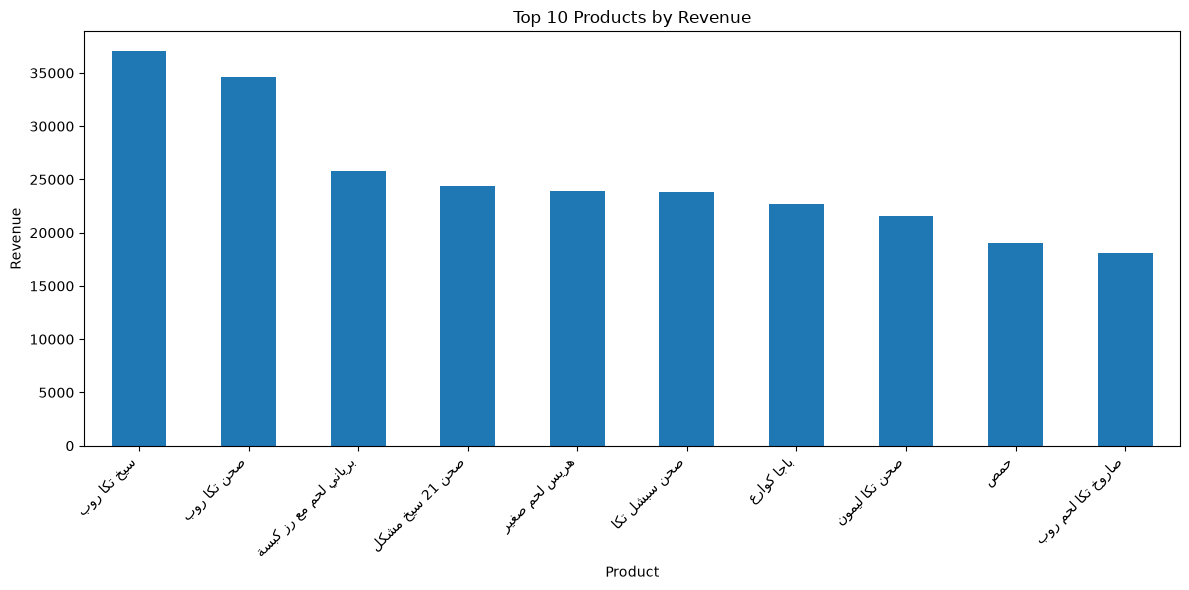

In [36]:
plt.figure(figsize=(12, 6))

top_revenue_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.2 Top 10 Products by Quantity Sold

Visualize the ten products with the highest sales volume.

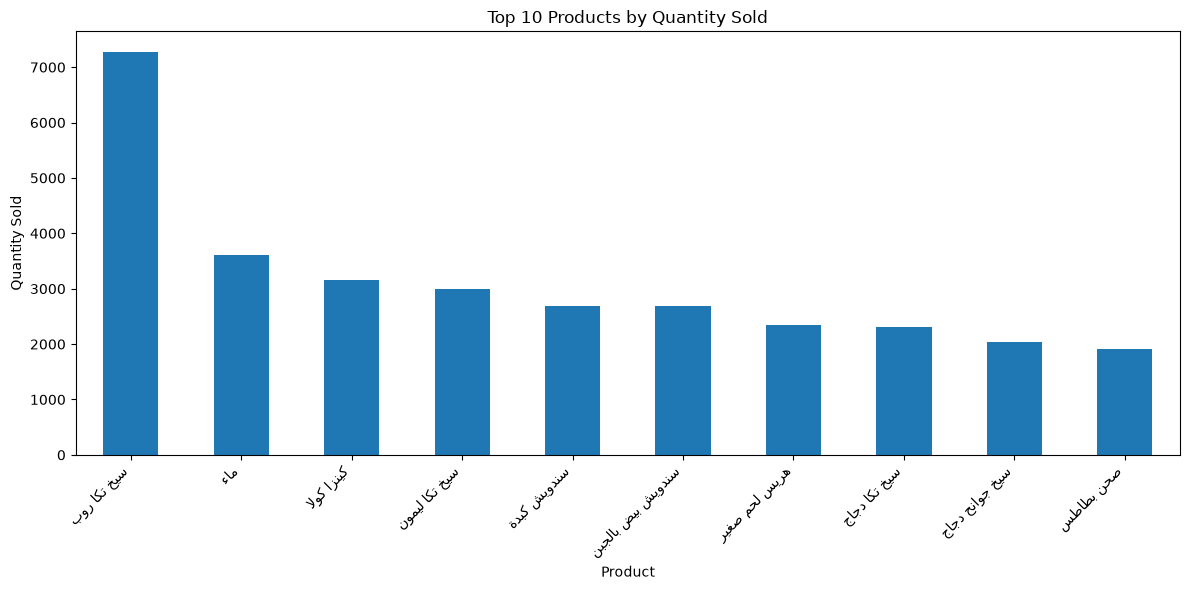

In [37]:
plt.figure(figsize=(12, 6))

top_quantity_products.head(10).plot(kind="bar")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.3 Lowest-Selling Products

Visualize the products with the lowest sales quantity.

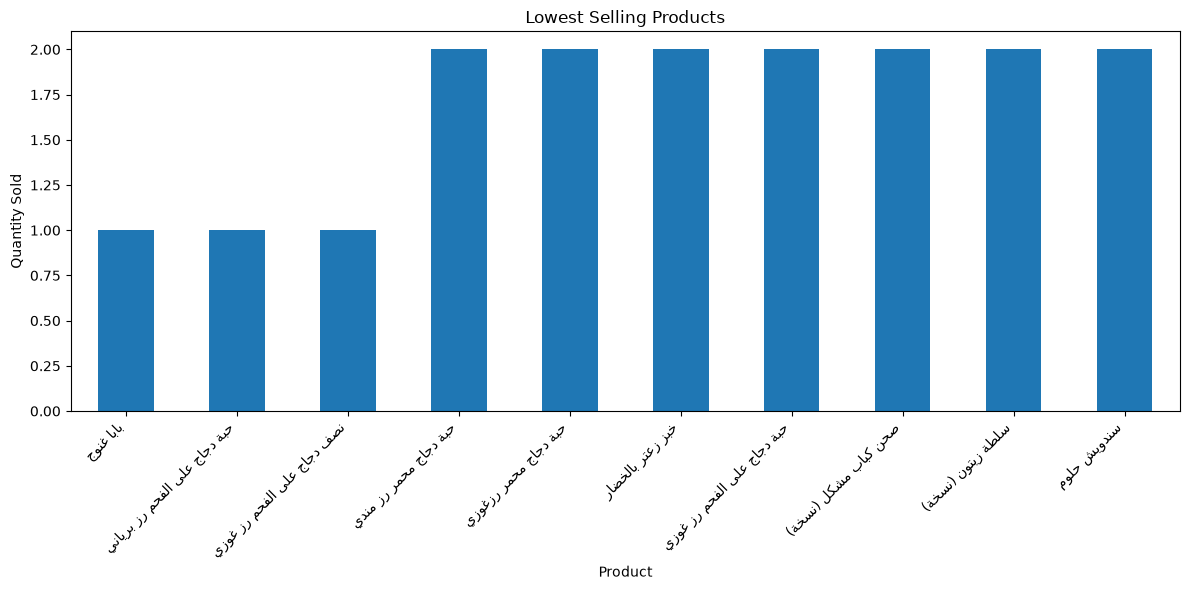

In [38]:
plt.figure(figsize=(12, 6))

lowest_products.head(10).plot(kind="bar")

plt.title("Lowest Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.4 Most Returned Products

Visualize the products with the highest number of returned items.

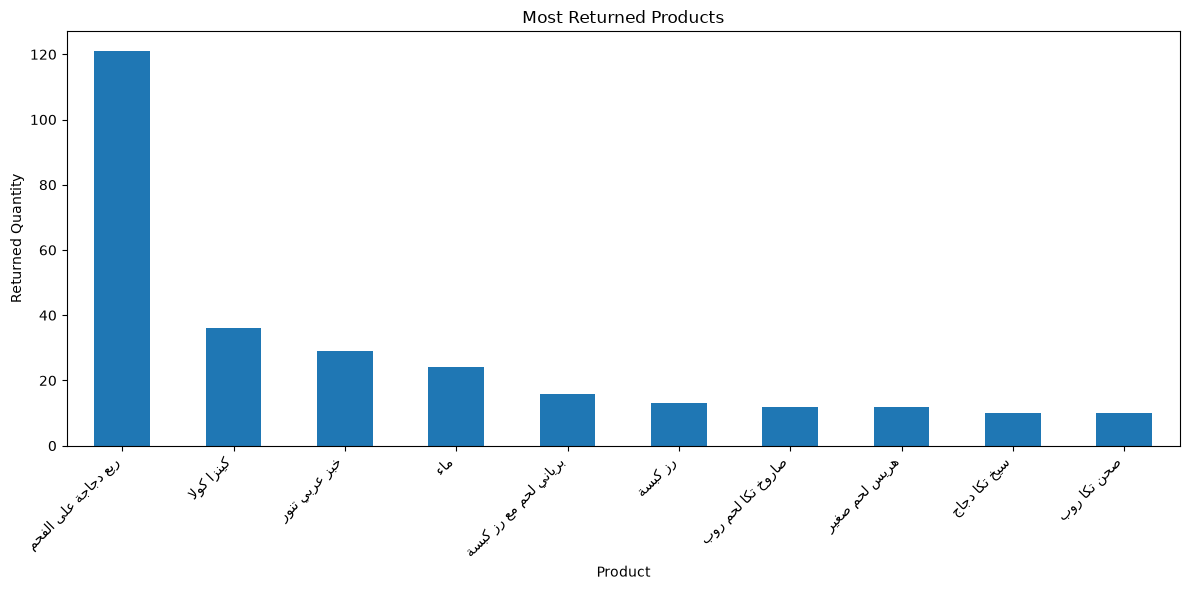

In [39]:
plt.figure(figsize=(12, 6))

returned_products.head(10).plot(kind="bar")

plt.title("Most Returned Products")
plt.xlabel("Product")
plt.ylabel("Returned Quantity")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 8.5 Monthly Sales

Visualize the total sales revenue for each month.

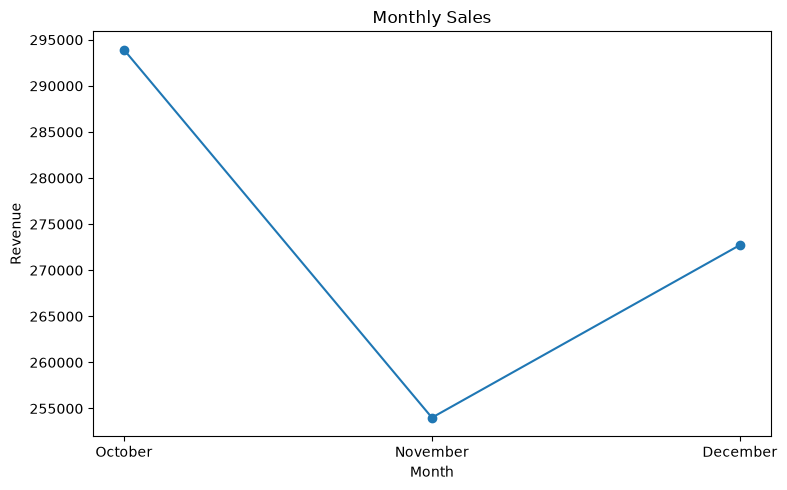

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Subtotal"],
    marker="o"
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.6 Sales by Weekday

Visualize sales revenue across the days of the week.

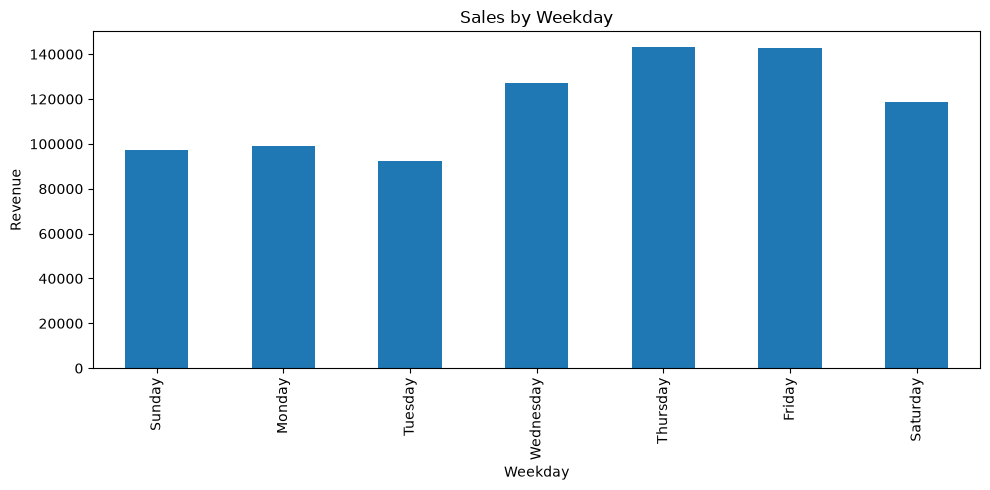

In [41]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(kind="bar")

plt.title("Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### 8.7 Sales by Hour

Visualize hourly sales revenue to identify peak business hours.

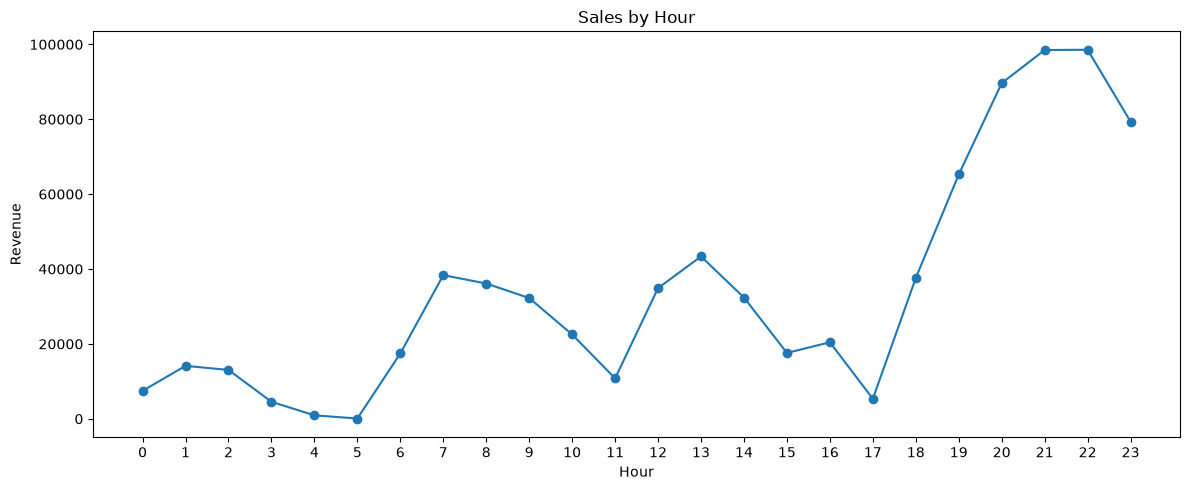

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_sales.index,
    hourly_sales.values,
    marker="o"
)

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

### 8.8 Revenue by Delivery Platform

Visualize the sales revenue generated by each delivery platform.

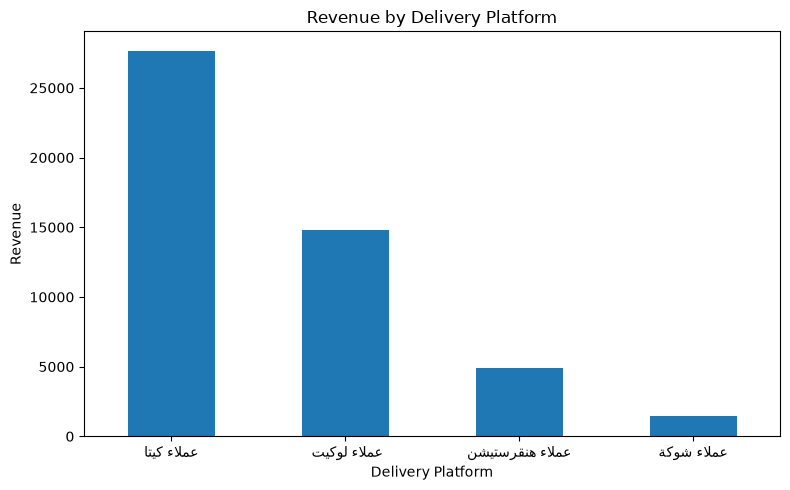

In [43]:
plt.figure(figsize=(8, 5))

platform_sales.plot(kind="bar")

plt.title("Revenue by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.9 Orders by Delivery Platform

Visualize the number of orders received from each delivery platform.

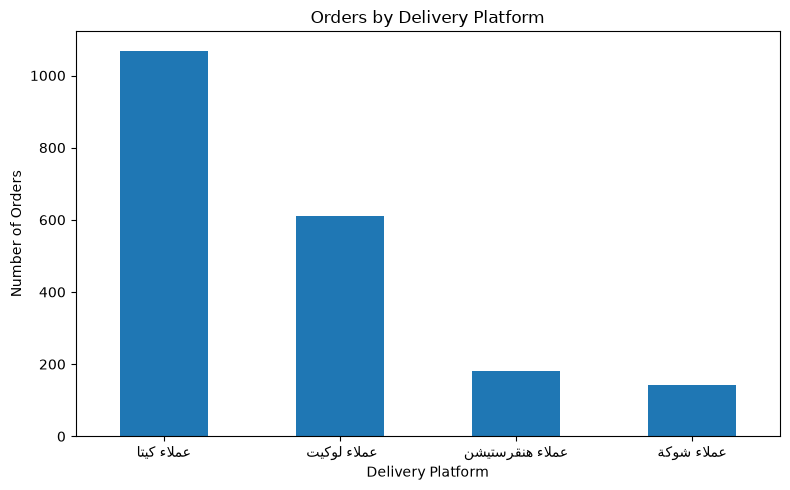

In [44]:
plt.figure(figsize=(8, 5))

platform_orders.plot(kind="bar")

plt.title("Orders by Delivery Platform")
plt.xlabel("Delivery Platform")
plt.ylabel("Number of Orders")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 8.10 Delivery Platform Revenue Contribution

Visualize the percentage contribution of each delivery platform to the total sales revenue.

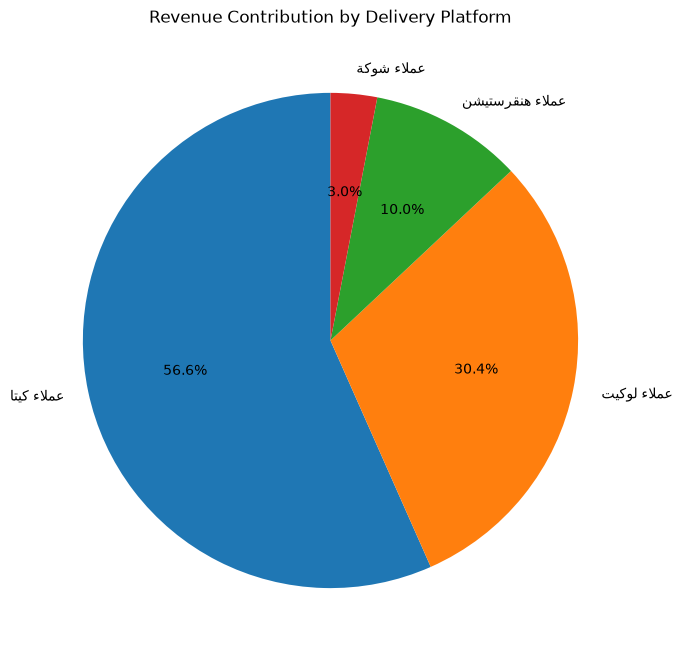

In [45]:
plt.figure(figsize=(7, 7))

plt.pie(
    platform_contribution,
    labels=platform_contribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Contribution by Delivery Platform")

plt.tight_layout()
plt.show()

## 9. Key Insights

- The fourth quarter generated a total revenue of **821,026.40** from **20,819** completed orders, with an average order value of **39.44**.
- The cleaned dataset contains **169 unique products**, **792 unique customers**, and **20,819** unique transactions, providing a comprehensive overview of sales activity during the fourth quarter.
- **October** recorded the highest sales revenue (**294,087.48**) and the highest number of orders (**7,428**), making it the best-performing month of the quarter.
- **Thursday** generated the highest sales revenue and also recorded the largest number of completed orders, indicating that it was the busiest day of the week.
- Sales revenue peaked at **10:00 PM (22:00)**, while the highest number of orders was recorded at **7:00 AM (07:00)**, reflecting different customer purchasing patterns throughout the day.
- **سيخ تكا روب** generated the highest sales revenue, followed by **صحن تكا روب** and **برياني لحم مع رز كبسة**, making them the leading revenue-generating products during the quarter.
- **سيخ تكا روب** recorded the highest sales quantity, followed by **ماء** and **كينزا كولا**, indicating strong customer demand for these products.
- Among the analyzed delivery platforms, **عملاء كيتا** generated the highest sales revenue and recorded the largest number of completed orders, while **عملاء هنقرستيشن** achieved the highest average order value.
- The highest returned quantities were observed for **ربع دجاجة على الفحم**, **كينزا كولا**, and **خبز عربي تنور**, suggesting that these products experienced more returns than other items during the analyzed period.